The point of this notebook is to estimate EC parameters that would lead to an efficiency of 30%, and then to plug those parameters into SunSolve. 
Specifically, editing the generic module to have pvk thickness of 800nm and fingers of 2.27cm (it doesn't allow 2.5) 
Note that the pvk in sunsolve has Eg of 1.64eV, and Si thickness is 182um

Step 1: setup and library import -- boring stuff

In [5]:
# libraries # numpy, matplotlib, pandas, scipy, PySpice, gc, time, ctypes, os, sys, platform, pathlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve, least_squares
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.stats import linregress

import gc
import time

import os
import sys
import platform
from pathlib import Path   

# to be able to use PySpice you  need to install the ngspice library
# and set the NgSpiceShared.library_path to the ngspice.dll file location -- .dylib for mac
# Visit:https://pyspice.fabrice-salvaire.fr/releases/v1.4/overview.html and https://ngspice.sourceforge.io/
# to find out about PySpice and NgSpice installation instructions.

# for ease: visit https://sourceforge.net/projects/ngspice/files/ng-spice-rework/44.2/
# and download  ngspice-44.2_dll_64.7z
# I include here a link to a pre-compiled ngspice.dll
# file for Windows, in ./data/ngspice.dll (downloaded July 2025)

# cross-platform ngspice loader
import os
import sys
import platform
import ctypes
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve, least_squares, root_scalar
from scipy.interpolate import interp1d
from scipy.stats import linregress
import gc, time

from PySpice.Spice.Netlist import Circuit
from PySpice.Spice.NgSpice.Shared import NgSpiceShared

# --- configure ngspice path & load ---
system = platform.system()

# if macOS
if system == "Darwin":
    # Assumes Homebrew-installed ngspice on macOS
    dylib = Path("/opt/homebrew/lib/libngspice.dylib")
    if not dylib.exists():
        raise FileNotFoundError(f"{dylib} not found. Install ngspice via Homebrew or specify path.")
    NgSpiceShared.library_path = str(dylib)
    ctypes.cdll.LoadLibrary(str(dylib))
    print("Loaded ngspice dylib from", dylib)

# if Windows
elif system == "Windows":
    # Prefer conda env install: <env>/Library/bin/ngspice.dll
    env_libbin = Path(sys.prefix) / "Library" / "bin"
    env_dll = env_libbin / "ngspice.dll"

    # choose which DLL to use
    if env_dll.exists():
        chosen = env_dll
        add_dirs = [env_libbin]
    else:
        raise FileNotFoundError(
            f"ngspice.dll not found. Checked:\n  {env_dll}\n  {data_dll}\n"
            "Install ngspice into your conda env (conda install -c conda-forge ngspice)"
        )
    
    '''
    # add DLL search dirs for this process (Python 3.8+)
    for d in add_dirs:
        if d.exists():
            try:
                os.add_dll_directory(str(d))
            except Exception:
                # non-fatal: older Python or platform quirk
                pass
    '''

    NgSpiceShared.library_path = str(chosen)
    try:
        ctypes.CDLL(str(chosen))
        print("Loaded ngspice DLL from", chosen)
    except OSError as e:
        # helpful diagnostic
        print("Failed to load ngspice.dll:", e)
        raise

else:
    raise RuntimeError("Unsupported platform: " + system)

# --- rest of your code below ---
# from here on you can use PySpice and the other imports as usual


from PySpice.Spice.Netlist import Circuit
from PySpice.Spice.NgSpice.Shared import NgSpiceShared

import tandex_func_02 as tandex  # this is the main module for TandEx including all background functions

# to auto-reload modules when they are changed
%load_ext autoreload 
%autoreload 2

Loaded ngspice DLL from c:\Users\linc5977\AppData\Local\anaconda3\envs\pyspice\Library\bin\ngspice.dll
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Step 2 -- define constants

In [6]:
# Constants
k = 1.380649e-23  # Boltzmann constant in J/K
q = 1.60217662e-19  # Electron charge in C
epsrox = 3.9  # epsilon, relative, oxide --> relative permitivity of silicon oxide
eps0 = 8.85e-14  # F/cm epsilon nought --> permitivity of free space
epsrs = 11.9  # epsilon, relative, semiconductor --> relative permitivity of silicon
T = 298.15  # K
Vt = (k * T) / q  # eV
hc = 1240  # eV*nm
c = 3e8  # m/s
Pin = 0.1  # W/cm^2 -- irradiance

get am1.5g

In [7]:
# Parameters #

data = np.load("./data/AM15g_spectrum.npz")  # load AM1.5g spectrum
# LambdaVar in nm, and AM15gFlux in s^-1*cm^-2*nm^-1

# generate a well-defined version
lambda_vec = np.arange(250, 1400, 5)  # vector of wavelengths in nm
AM15g = np.interp(lambda_vec, data["LambdaVar"], data["AM15gFlux"])

Now we get to the interesting part -- defining cell parameters

In [8]:
# top cell parameters [Lead Halide Perovskite FACsPbIBr]
EgapP = 1.64  # bandgap (eV)d
pvk_thick = 800e-7  # cm
Rsh_pvk = 200e3  # Shunt resistance in ohms.cm2
J01d_pvk = 8e-24  # A/cm2
J02_pvk = 2.1e-13  # A/cm2
J0def_pvk = 3e-23  # A/cm2
Rdef_pvk = 12  # ohms.cm2

w = 1  # Unit cell dimensions (cm)
l = 2.26  #  pitch (cm) 

# bottom cell parameters [Silicon]
EgapSi = 1.12  # bandgap (eV)
Rsh_Si = 50e3  # Shunt resistance (ohms.cm2)
Waf_thick = 0.0182  # cm, 182um
Ndop = 5e14  # Doping concentration (cm^-3)
dop_type = -1  # n-type -1, p-type +1
ni = 9.65e9  # Intrinsic carrier concentration (cm^-3)
n_def = 1  # ideality factor for SRH recombination
J0n_Si = 2e-15  # A/cm2 -- (dark) saturation current density due to diffusion and SRH

C_aug = 2.945e-30  # Auger recombination coefficient (cm^6/s)
J0Aug_Si = q * C_aug * ni**3 * Waf_thick  # Auger recombination current A/cm2

# combined series resistance from internal transport factors
RserInt = 1.5 + 4.7e-3  # ohms.cm2 - internal series resistance (pvk + Si).

# Black body spectrum at 300K temperature
BB300K = (
    2 * np.pi * c / ((lambda_vec * 1e-9) * lambda_vec * (lambda_vec * 1e-7) ** 2)
) * (
    1.0 / (np.exp(hc / (lambda_vec * Vt)) - 1)
)  # embedded unit conversions --what are the final units on this??

artificially shift bandgap to 1.64

Met condition, breaking


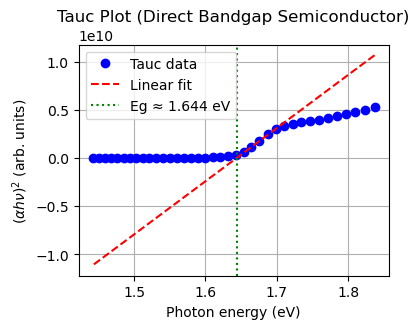

In [9]:
# tauc analysis of the absorption coefficient in the perovsite

file_path = "./data/CsFaPbIB_1,72_Tejada2018.csv"
df_pvk0 = pd.read_csv(file_path)

Erange = [
    EgapP - 0.2,
    EgapP + 0.2,
]  # specify the range of energy to do the tauc fitting

results = []
i = 1
lambda_shift = 0

while i < 1000:
    E_gap, df_new_nk = tandex.tauc_analysis(
        df_pvk0, lambda_shift, lambda_vec, Erange, plot=False
    )
    results.append({"lambda_shift": lambda_shift, "E_gap": E_gap})
    if np.abs(E_gap - EgapP) < 0.004:
        print("Met condition, breaking")
        break
    if E_gap > EgapP:
        lambda_shift += 1
    elif E_gap < EgapP:
        lambda_shift -= 1
    i += 1
E_gap, df_new_nk = tandex.tauc_analysis(
    df_pvk0, lambda_shift, lambda_vec, Erange, plot=True
)

# write new file with the modified nk data
df_new_nk.to_csv(r"./data/pvk_nk_data.csv", index=False)

Optical simulation

Weighted Average Transmittance into the Si: 48.94 %
Weighted Average Absorption in PVK: 41.54 %
Weighted Average Reflection: 6.20 %
Jsc_pvk = 21.72665 mA/cm^2
Jsc_Si = 18.69373 mA/cm^2


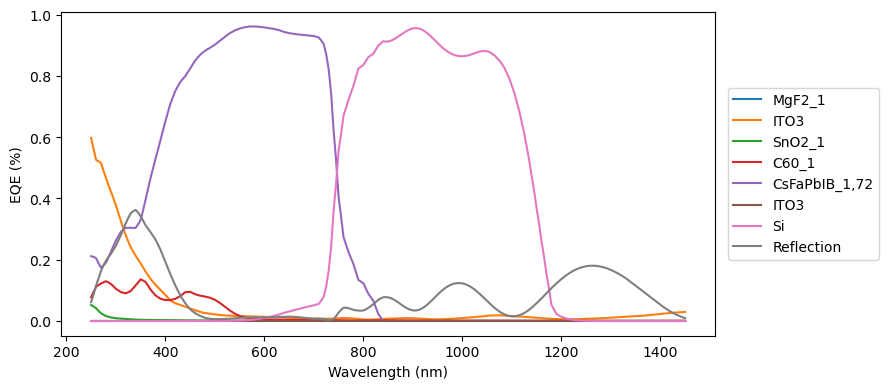

In [ ]:
# we begin with the optical simulation of the tandem cell stack
AM15g_spectrum = np.load(
    "./data/AM15g_spectrum.npz"
)  # a numpy file with AM1.5g spectrum

TCE_thick = 40e-7  # cm
TCE_rho = 0.42e-3  # Ω·cm, example value for TCO

layers = ["Air", "MgF2_1", "ITO3", "SnO2_1", "C60_1", "CsFaPbIB_1,72", "ITO3", "Si_"]
thicknesses = np.array(
    [0, 115, TCE_thick * 1e7, 20, 10, pvk_thick * 1e7, 2, 5000]
)  # (nm)
# ignore the Si thickness, 1um only for calculating the Pvk.

pvk_layer_id = 5  # indexing starts from 0

lambda_start = (
    250  # build a wavelength range to calculate over, starting wavelength (nm)
)
lambda_stop = 1450  # final wavelength (nm)
lambda_step = 5  # wavelength step size

x_step = 1  # grid spacing of device cross section simulation in nm

lambda_vec = np.arange(
    lambda_start, lambda_stop + lambda_step, lambda_step, float
)  # wavelength range in nm
AM15g = np.interp(
    lambda_vec, AM15g_spectrum["LambdaVar"], AM15g_spectrum["AM15gFlux"]
)  #  nm , s^-1*cm^-2*nm^-1

front_layers = np.arange(0, 6)  # layers in front of silicon layer

# obtain the complex refractive index for all layers from the excel database
excel_path = "./data/Optical_Properties.xlsx"
df_nk_excel = pd.read_excel(excel_path, header=0, sheet_name=0)
n_k = np.zeros((len(layers), len(lambda_vec)), dtype=complex)

# load index of refraction for each material in the stack, in the variable n_k
for i, l in enumerate(layers):
    n_k_i = np.array(tandex.get_ntotal_from_excel(l, lambda_vec, df_nk_excel))
    n_k[i, :] = n_k_i

# correct the n_k values to account for the exact bangap in the pvk_layer
df_pvk_tmm = pd.DataFrame(columns=df_pvk0.columns)
df_pvk_tmm["lambda_k"] = lambda_vec
df_pvk_tmm["alpha"] = (4 * np.pi * n_k[pvk_layer_id, :].imag) / (lambda_vec * 1e-7)
lambda_shift = tandex.get_lambda_shift(EgapP, lambda_vec, df_pvk_tmm)
int_n = interp1d(
    lambda_vec + lambda_shift,
    n_k[pvk_layer_id, :].real,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate",
)
int_k = interp1d(
    lambda_vec + lambda_shift,
    n_k[pvk_layer_id, :].imag,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate",
)
new_n_k = np.array(
    [complex(n, k) for n, k in zip(int_n(lambda_vec), int_k(lambda_vec))]
)
n_k[pvk_layer_id, :] = new_n_k

# TMM_Tx_Ax returns Absorption as [layer, wavelength], Reflection as [wavelength]
TotalTx, Absorption, Reflection, E, x_pos, n = tandex.TMM_Tx_Ax(
    layers, thicknesses, lambda_vec, x_step, front_layers, n_k
)

WAT = np.dot(AM15g, TotalTx) / np.sum(AM15g)
print(f"Weighted Average Transmittance into the Si: {100*WAT:.2f} %")
print(
    f"Weighted Average Absorption in PVK: {100*np.sum(AM15g*Absorption[pvk_layer_id,:])/np.sum(AM15g):.2f} %"
)
print(
    f"Weighted Average Reflection: {100*np.sum(AM15g*Reflection)/np.sum(AM15g):.2f} %"
)

Jsc_pvk = q * np.trapezoid(AM15g * Absorption[pvk_layer_id, :], lambda_vec)  # A/cm2
print(f"Jsc_pvk = {Jsc_pvk*1e3:.5f} mA/cm^2")

# Plot normalized intensity absorbed / cm3-nm at each layer and wavelength
fig2 = plt.figure(figsize=(9, 4))
ax2 = fig2.add_subplot(111)
ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel("EQE (%)")


for matind in range(1, len(layers) - 1):
    ax2.plot(lambda_vec, Absorption[matind, :], label=layers[matind])

EQE_pvk = Absorption[pvk_layer_id, :] # External quantum efficiency of the perovskite without any electrical losses

# Silicon absorption and Jsc are calculated via Green's model for lambertian absorption
FilteredAM15g = AM15g * TotalTx  # Filtered AM15g spectrum after the top cell
Jsc_Si, AxSi = tandex.Jsc_Si_func(Waf_thick, lambda_vec, FilteredAM15g)
EQE_Si = FilteredAM15g * AxSi / AM15g # External quantum efficiency of the silicon without any electrical losses

print(f"Jsc_Si = {1e3*Jsc_Si:.5f} mA/cm^2")

ax2.plot(lambda_vec, EQE_Si, label="Si")
ax2.plot(lambda_vec, Reflection, label="Reflection")
ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, borderaxespad=0)
plt.tight_layout()
plt.show()

top cell parameters
Isc_pvk []: -0.0026832
Rsh_pvk []: 1.6e+06
I0_pvk + I01d_pvk []: 1.5467e-24
I0def_pvk []: 3.75e-24
Rdef_pvk []: 96.00
I02_pvk []: 2.625e-14
bottom cell parameters
Isc_Si []: -0.00231
Rsh_Si []: 400000.00
I01_Si []: 3.8865e-17
I0Aug_Si []: 9.6463e-22
I0n_Si []: 2.5e-16
n_def []: 1
Maximum Efficiency: 32.36 %
Jsc: 18.49 mA/cm^2
Voc: 1.97 V
FF: 0.89


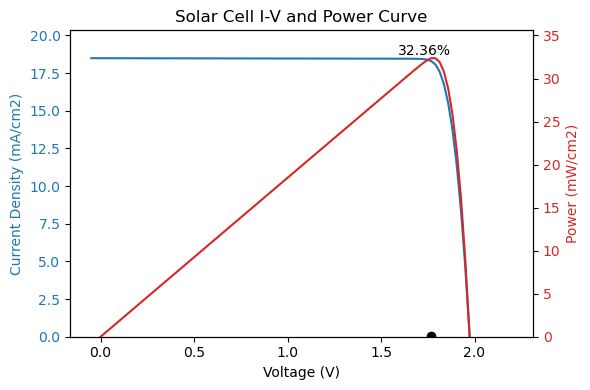

In [24]:
# Electrical simulation

R_tco = TCE_rho / (TCE_thick)  # TCO sheet resistance (Ω/sq)

# combined series resistance from internal factors
RserInt = 1.5 + 4.7e-3  # ohms.cm2 - internal series resistance (pvk + Si).

BB300K = (
    2 * np.pi * c / ((lambda_vec * 1e-9) * lambda_vec * (lambda_vec * 1e-7) ** 2)
) * (1.0 / (np.exp(hc / (lambda_vec * Vt)) - 1))

w = 1  # Unit cell dimensions (cm)
d = 30e-4  # Contact width in cm -- 30um
l = 0.25
AAF = 1 - d / l

Vcell = np.linspace(-0.05, 2.2, 100)  # the voltage range for the cell simulation

J0_pvk = q * np.trapezoid(BB300K * EQE_pvk, lambda_vec)
J0_Si = q * np.trapezoid(BB300K * EQE_Si, lambda_vec)

# Re-calculate the currents, based on the optimal pitch. Units of Amperes
# perovskite top cell
Isc_pvk = -AAF * w * (l / 2) * Jsc_pvk
I0_pvk = w * (l / 2) * J0_pvk
I01d_pvk = (w * (l / 2)) * J01d_pvk

# silicon bottom cell
Isc_Si = -AAF * w * (l / 2) * Jsc_Si
I01_Si = w * (l / 2) * J0_Si

Rser = (
    R_tco * (l**2 / (12)) + RserInt
)  # series resistance in ohms.cm^2 [TCO + external]

# top cell parameters: Isc_pvk, Rsh_pvk, I0_pvk, I0def_pvk, Rdef_pvk, I02_pvk
top_cell = [
    Isc_pvk,
    Rsh_pvk / (w * (l / 2)),
    I0_pvk + I01d_pvk,
    J0def_pvk * w * (l / 2),
    Rdef_pvk / (w * (l / 2)),
    J02_pvk * w * (l / 2),
]
# bottom cell parameters: Isc_Si, Rsh_Si, I01_Si, I0Aug_Si, I0d_Si, n_def
bottom_cell = [
    Isc_Si,
    Rsh_Si / (w * (l / 2)),
    I01_Si,
    J0Aug_Si * w * (l / 2),
    J0n_Si * w * (l / 2),
    n_def,
]

print('top cell parameters')
print(f"Isc_pvk []: {top_cell[0]:.5g}")
print(f"Rsh_pvk []: {top_cell[1]:.2g}")
print(f"I0_pvk + I01d_pvk []: {top_cell[2]:.5g}")
print(f"I0def_pvk []: {top_cell[3]:.5g}")
print(f"Rdef_pvk []: {top_cell[4]:.2f}")
print(f"I02_pvk []: {top_cell[5]:.5g}")

print('bottom cell parameters')
print(f"Isc_Si []: {bottom_cell[0]:.5f}")
print(f"Rsh_Si []: {bottom_cell[1]:.2f}")
print(f"I01_Si []: {bottom_cell[2]:.5g}")
print(f"I0Aug_Si []: {bottom_cell[3]:.5g}")
print(f"I0n_Si []: {bottom_cell[4]:.5g}")
print(f"n_def []: {bottom_cell[5]:.5g}")

voltages, currents = tandex.simulate_circuit(top_cell, bottom_cell, Rser, w, l, Vcell)

eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, False)

print(f"Maximum Efficiency: {eff:.2f} %")
print(f"Jsc: {Jsc*1e3:.2f} mA/cm^2")
print(f"Voc: {Voc:.2f} V")
print(f"FF: {FF:.2f}")
eff, Jsc, Voc, FF = tandex.calculate_efficiency(voltages, currents, True)